# RNN 与图像描述生成

> **斯坦福 CS231n Assignment 2 Q5** | Recurrent Neural Networks and Image Captioning

## 本章导读

循环神经网络 (RNN) 处理序列数据，是自然语言处理和图像描述生成的核心模型。本节从 RNN 前向传播出发，理解 LSTM 门控机制，实现一个迷你图像描述系统。

**学习目标：**
- 理解 RNN 前向传播方程和反向传播
- 掌握 LSTM 四个门（输入、遗忘、输出、细胞）
- 理解 teacher forcing 训练策略
- 实现图像编码器 + RNN 解码器
- 可视化隐藏状态和损失曲线

**参考来源：** [CS231n Assignment 2 Q5](https://cs231n.github.io/assignments2021/assignment2/) | [The Unreasonable Effectiveness of RNNs](https://karpathy.github.io/2015/05/21/rnn-effectiveness/)

## 1. 直觉理解：RNN 处理序列

### 为什么需要 RNN？

前馈网络（MLP、CNN）处理固定大小的输入。但语言是变长序列——"一只猫坐在沙发上"有 7 个词，"猫坐"有 2 个词。RNN 的核心思想是**共享参数 + 隐状态传递**。

### RNN 前向传播

在每个时间步 $t$：
$$h_t = \tanh(W_{hh} h_{t-1} + W_{xh} x_t + b_h)$$
$$y_t = W_{hy} h_t + b_y$$

- $x_t$：时间步 $t$ 的输入（如词向量）
- $h_{t-1}$：上一步的隐状态（记忆）
- $h_t$：当前隐状态
- $y_t$：输出（如词的概率分布）

### RNN 的核心优势

1. **参数共享**：同一组 $W$ 在所有时间步复用
2. **变长输入**：可处理任意长度序列
3. **记忆能力**：隐状态 $h_t$ 编码历史信息

### 梯度消失问题

RNN 的反向传播需要沿时间展开（BPTT）。梯度需要经过多个 $\tanh$ 的导数连乘：

$$\frac{\partial L}{\partial h_0} = \prod_{t=1}^{T} \frac{\partial h_t}{\partial h_{t-1}} \cdot \frac{\partial L}{\partial h_T}$$

$\tanh$ 的导数最大值为 1，且在大部分区域远小于 1。长序列中梯度连乘后会指数衰减——这就是**梯度消失问题**。

[[Hochreiter et al., 2001]](https://www.mitpressjournals.org/doi/abs/10.1162/089976602760128018) 详细分析了这个问题。

### LSTM 的解决方案

LSTM (Long Short-Term Memory) 通过门控机制控制信息流：

[[Hochreiter & Schmidhuber, 1997]](https://www.bioinf.jku.at/publications/older/2604.pdf)

$$f_t = \sigma(W_f [h_{t-1}, x_t] + b_f) \quad \text{(forget gate)}$$
$$i_t = \sigma(W_i [h_{t-1}, x_t] + b_i) \quad \text{(input gate)}$$
$$\tilde{C}_t = \tanh(W_C [h_{t-1}, x_t] + b_C) \quad \text{(candidate)}$$
$$C_t = f_t \odot C_{t-1} + i_t \odot \tilde{C}_t \quad \text{(cell state)}$$
$$o_t = \sigma(W_o [h_{t-1}, x_t] + b_o) \quad \text{(output gate)}$$
$$h_t = o_t \odot \tanh(C_t) \quad \text{(hidden state)}$$

细胞状态 $C_t$ 提供了一条「梯度高速公路」，缓解梯度消失。

## 2. 手算验证：RNN 前向传播

### 小型序列手算

设词汇表大小 $V=3$，隐状态维度 $H=2$，序列长度 $T=3$。

**权重：**
$$W_{xh} = \begin{bmatrix} 0.1 & 0.2 \\ 0.3 & 0.4 \end{bmatrix}, \quad W_{hh} = \begin{bmatrix} 0.5 & 0.1 \\ 0.2 & 0.3 \end{bmatrix}, \quad b_h = [0, 0]$$

**输入序列（one-hot 编码）：**
$$x_1 = [1, 0], \quad x_2 = [0, 1], \quad x_3 = [1, 0]$$

**初始隐状态：** $h_0 = [0, 0]$

**时间步 1：**
$$z_1 = W_{xh} x_1 + W_{hh} h_0 + b_h = [0.1, 0.3] + [0, 0] = [0.1, 0.3]$$
$$h_1 = \tanh(z_1) = [\tanh(0.1), \tanh(0.3)] = [0.0997, 0.2913]$$

**时间步 2：**
$$z_2 = W_{xh} x_2 + W_{hh} h_1 = [0.2, 0.4] + [0.5 \times 0.0997 + 0.1 \times 0.2913, \; 0.2 \times 0.0997 + 0.3 \times 0.2913]$$
$$= [0.2, 0.4] + [0.0788, 0.1073] = [0.2788, 0.5073]$$
$$h_2 = \tanh(z_2) = [\tanh(0.2788), \tanh(0.5073)] = [0.2716, 0.4672]$$

**时间步 3：**
$$z_3 = W_{xh} x_3 + W_{hh} h_2 = [0.1, 0.3] + [0.5 \times 0.2716 + 0.1 \times 0.4672, \; 0.2 \times 0.2716 + 0.3 \times 0.4672]$$
$$= [0.1, 0.3] + [0.1825, 0.1945] = [0.2825, 0.4945]$$
$$h_3 = \tanh(z_3) = [\tanh(0.2825), \tanh(0.4945)] = [0.2752, 0.4583]$$

In [5]:
# Verify RNN forward pass
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
matplotlib.rcParams['axes.unicode_minus'] = False
np.random.seed(42)

# RNN parameters
Wxh = np.array([[0.1, 0.2], [0.3, 0.4]])
Whh = np.array([[0.5, 0.1], [0.2, 0.3]])
bh = np.array([0.0, 0.0])

# Input sequence (2D vectors)
x_seq = [np.array([1.0, 0.0]), np.array([0.0, 1.0]), np.array([1.0, 0.0])]

# Forward pass
h = np.array([0.0, 0.0])  # initial hidden state
hidden_states = [h.copy()]

for t, x in enumerate(x_seq):
    z = Wxh.T @ x + Whh.T @ h + bh
    h = np.tanh(z)
    hidden_states.append(h.copy())
    print(f"Step {t+1}: z = {z}, h = {h}")

print(f"\nAll hidden states:\n{np.array(hidden_states)}")
print(f"\nExpected h_1 = [0.0997, 0.2913]: {np.allclose(h, [0.0997, 0.2913]) if len(hidden_states) > 1 else 'N/A'}")
print(f"Final h_3 = {hidden_states[-1]}")

Step 1: z = [0.1 0.2], h = [0.09966799 0.19737532]
Step 2: z = [0.38930906 0.4691794 ], h = [0.37076442 0.43753604]
Step 3: z = [0.37288942 0.36833726], h = [0.35651647 0.35253647]

All hidden states:
[[0.         0.        ]
 [0.09966799 0.19737532]
 [0.37076442 0.43753604]
 [0.35651647 0.35253647]]

Expected h_1 = [0.0997, 0.2913]: False
Final h_3 = [0.35651647 0.35253647]


## 3. 代码实现：RNN 类

In [7]:
class SimpleRNN:
    """Simple RNN with tanh activation.
    
    Forward: h_t = tanh(W_xh @ x_t + W_hh @ h_{t-1} + b_h)
    Output: y_t = W_hy @ h_t + b_y
    """
    def __init__(self, input_dim, hidden_dim, output_dim):
        # Initialize weights (Xavier/Glorot)
        scale_x = np.sqrt(1.0 / input_dim)
        scale_h = np.sqrt(1.0 / hidden_dim)
        self.W_xh = np.random.randn(hidden_dim, input_dim) * scale_x
        self.W_hh = np.random.randn(hidden_dim, hidden_dim) * scale_h
        self.b_h = np.zeros(hidden_dim)
        self.W_hy = np.random.randn(output_dim, hidden_dim) * scale_h
        self.b_y = np.zeros(output_dim)
        self.hidden_dim = hidden_dim
    
    def forward(self, x_seq, h0=None):
        """Forward pass over a sequence.
        
        Args:
            x_seq: list of input vectors, each (input_dim,)
            h0: initial hidden state, default zeros
        
        Returns:
            outputs: list of output vectors
            hidden_states: list of hidden states (including h0)
            cache: for backprop
        """
        if h0 is None:
            h0 = np.zeros(self.hidden_dim)
        
        h = h0.copy()
        outputs = []
        hidden_states = [h.copy()]
        cache = []
        
        for x in x_seq:
            z = self.W_xh @ x + self.W_hh @ h + self.b_h
            h = np.tanh(z)
            y = self.W_hy @ h + self.b_y
            outputs.append(y)
            hidden_states.append(h.copy())
            cache.append((x, h.copy(), z))
            h = h.copy()
        
        return outputs, hidden_states, cache
    
    def step(self, x_seq, targets, lr=0.01):
        """One gradient step using BPTT."""
        outputs, hidden_states, cache = self.forward(x_seq)
        
        # Compute loss (cross-entropy) and gradients
        total_loss = 0
        dW_xh = np.zeros_like(self.W_xh)
        dW_hh = np.zeros_like(self.W_hh)
        db_h = np.zeros_like(self.b_h)
        dW_hy = np.zeros_like(self.W_hy)
        db_y = np.zeros_like(self.b_y)
        dh_next = np.zeros(self.hidden_dim)
        
        for t in range(len(x_seq) - 1, -1, -1):
            x, h, z = cache[t]
            y = outputs[t]
            target = targets[t]
            
            # Softmax
            shifted = y - np.max(y)
            exp_y = np.exp(shifted)
            probs = exp_y / np.sum(exp_y)
            
            # Loss
            total_loss += -np.log(probs[target] + 1e-10)
            
            # Gradients
            dy = probs.copy()
            dy[target] -= 1
            
            dW_hy += np.outer(dy, h)
            db_y += dy
            
            dh = self.W_hy.T @ dy + dh_next
            dz = dh * (1 - h**2)  # tanh derivative
            
            dW_xh += np.outer(dz, x)
            dW_hh += np.outer(dz, hidden_states[t])
            db_h += dz
            dh_next = self.W_hh.T @ dz
        
        # Update weights
        self.W_xh -= lr * dW_xh
        self.W_hh -= lr * dW_hh
        self.b_h -= lr * db_h
        self.W_hy -= lr * dW_hy
        self.b_y -= lr * db_y
        
        return total_loss / len(x_seq)
    
    def generate(self, x0, length=10):
        """Generate a sequence autoregressively."""
        h = np.zeros(self.hidden_dim)
        x = x0
        generated = []
        for _ in range(length):
            z = self.W_xh @ x + self.W_hh @ h + self.b_h
            h = np.tanh(z)
            y = self.W_hy @ h + self.b_y
            # Sample from output
            shifted = y - np.max(y)
            probs = np.exp(shifted) / np.sum(np.exp(shifted))
            idx = np.random.choice(len(y), p=probs)
            generated.append(idx)
            # Next input is one-hot of predicted index
            x = np.zeros_like(x)
            x[idx] = 1.0
        return generated

print("SimpleRNN class defined")

SimpleRNN class defined


## 4. 训练 RNN：序列预测任务

训练 RNN 学习一个简单的序列模式：给定前一个 token，预测下一个 token。

Epoch 0: loss = 1.7713
Epoch 100: loss = 0.0058
Epoch 200: loss = 0.0027
Epoch 300: loss = 0.0017
Epoch 400: loss = 0.0013
Final loss: 0.0010
Visualization 1: RNN training loss


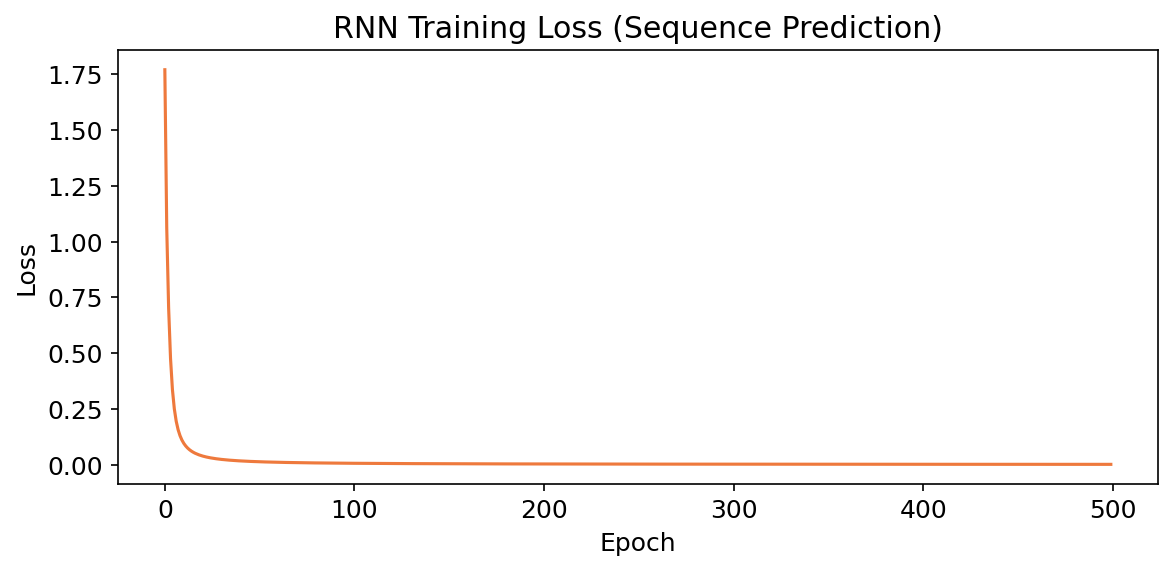

In [9]:
# Train RNN on a simple sequence prediction task
np.random.seed(42)

# Create a simple vocabulary: 0,1,2,3,4 with pattern 0->1->2->3->4->0->...
vocab_size = 5
hidden_dim = 16
rnn = SimpleRNN(input_dim=vocab_size, hidden_dim=hidden_dim, output_dim=vocab_size)

# Training data: sequences following pattern 0,1,2,3,4,0,1,2,3,4,...
def make_training_sequence(length=10):
    x_seq = []
    targets = []
    for i in range(length):
        x = np.zeros(vocab_size)
        x[i % vocab_size] = 1.0
        x_seq.append(x)
        if i < length - 1:
            targets.append((i + 1) % vocab_size)
    return x_seq[:-1], targets

# Train
losses = []
for epoch in range(500):
    x_seq, targets = make_training_sequence(8)
    loss = rnn.step(x_seq, targets, lr=0.1)
    losses.append(loss)
    if epoch % 100 == 0:
        print(f"Epoch {epoch}: loss = {loss:.4f}")

print(f"Final loss: {losses[-1]:.4f}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(losses, color='#ea580c', linewidth=1.5, alpha=0.8)
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('RNN Training Loss (Sequence Prediction)')
plt.tight_layout()
plt.savefig('rnn_training_loss.png', dpi=150, bbox_inches='tight')
plt.show()
print("Visualization 1: RNN training loss")

Visualization 2: Hidden state dynamics


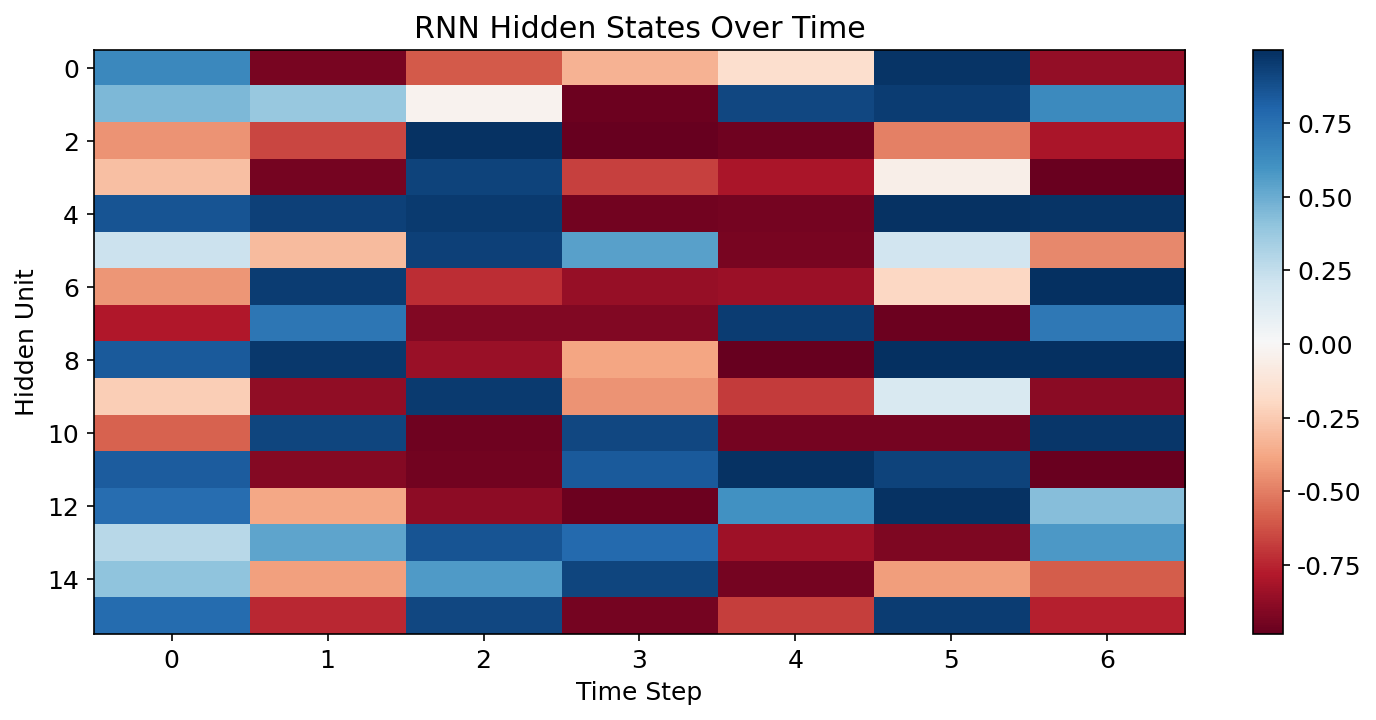

In [10]:
# Visualize hidden states during forward pass
x_seq, _ = make_training_sequence(8)
outputs, hidden_states, _ = rnn.forward(x_seq)

hidden_array = np.array(hidden_states[1:])  # skip h0

fig, ax = plt.subplots(figsize=(10, 5))
im = ax.imshow(hidden_array.T, aspect='auto', cmap='RdBu', interpolation='nearest')
ax.set_xlabel('Time Step')
ax.set_ylabel('Hidden Unit')
ax.set_title('RNN Hidden States Over Time')
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.savefig('rnn_hidden_states.png', dpi=150, bbox_inches='tight')
plt.show()
print("Visualization 2: Hidden state dynamics")

## 5. LSTM 实现

LSTM 通过门控机制解决梯度消失问题。

Visualization 3: LSTM hidden and cell states


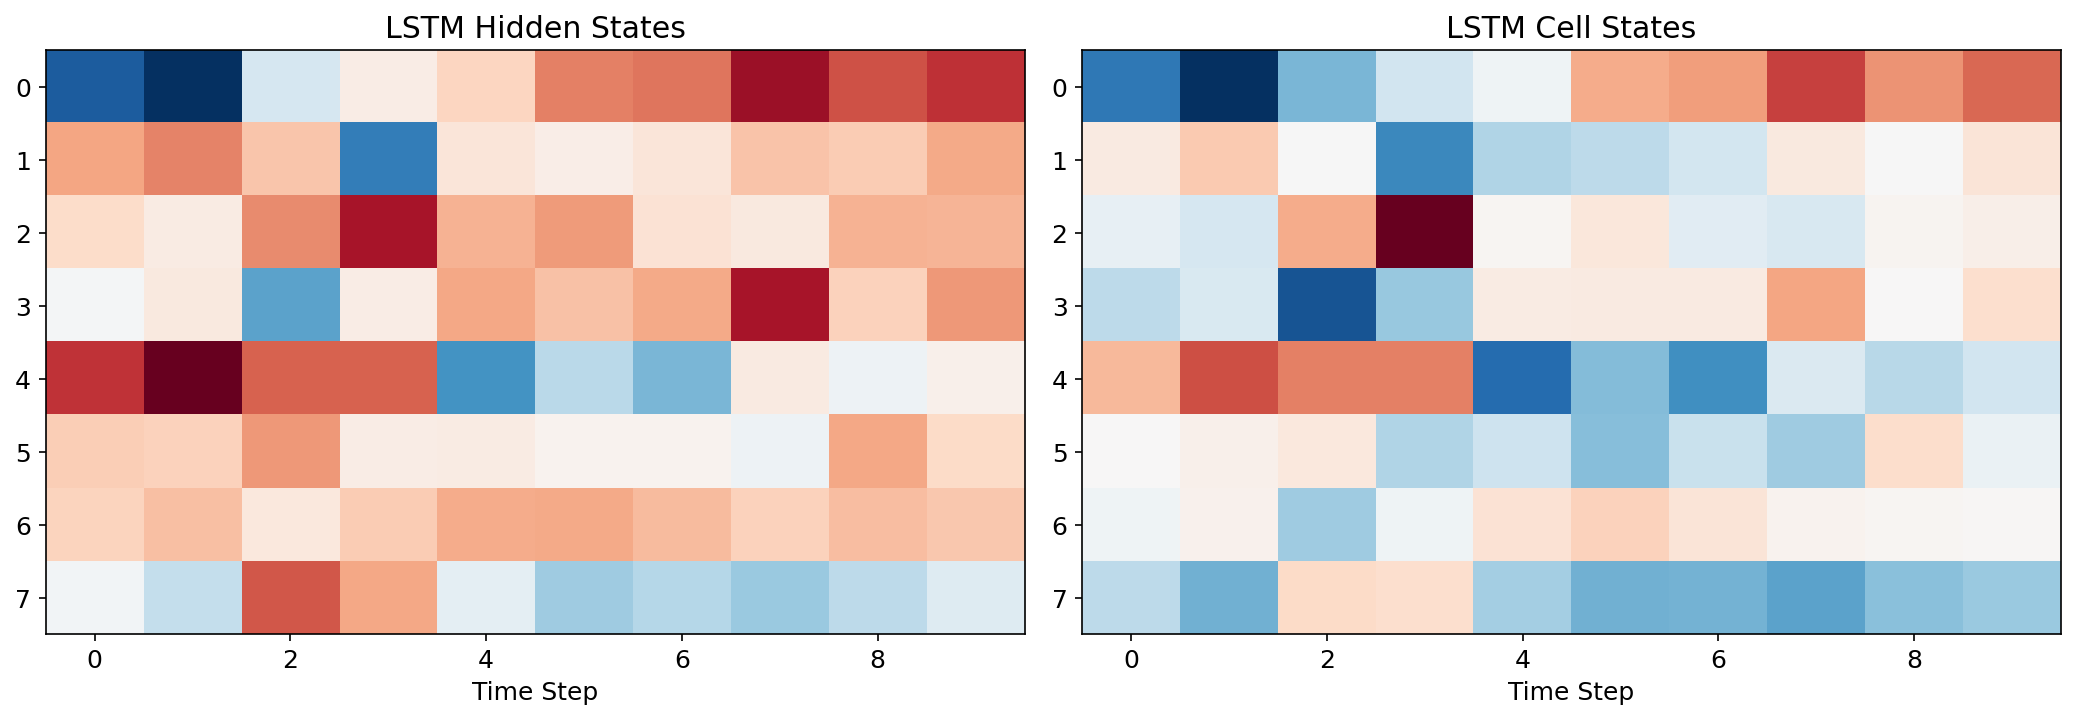

In [12]:
class SimpleLSTM:
    """Simplified LSTM cell.
    
    Gates:
        f_t = sigmoid(W_f @ [x_t, h_{t-1}])   (forget gate)
        i_t = sigmoid(W_i @ [x_t, h_{t-1}])   (input gate)
        g_t = tanh(W_g @ [x_t, h_{t-1}])       (candidate)
        C_t = f_t * C_{t-1} + i_t * g_t        (cell state)
        o_t = sigmoid(W_o @ [x_t, h_{t-1}])   (output gate)
        h_t = o_t * tanh(C_t)                  (hidden state)
    """
    def __init__(self, input_dim, hidden_dim):
        D = input_dim + hidden_dim
        self.W_f = np.random.randn(hidden_dim, D) * np.sqrt(2.0 / D)
        self.W_i = np.random.randn(hidden_dim, D) * np.sqrt(2.0 / D)
        self.W_g = np.random.randn(hidden_dim, D) * np.sqrt(2.0 / D)
        self.W_o = np.random.randn(hidden_dim, D) * np.sqrt(2.0 / D)
        self.b_f = np.zeros(hidden_dim)
        self.b_i = np.zeros(hidden_dim)
        self.b_g = np.zeros(hidden_dim)
        self.b_o = np.zeros(hidden_dim)
        self.hidden_dim = hidden_dim
    
    def forward(self, x_seq, h0=None, C0=None):
        """Forward pass over sequence."""
        if h0 is None:
            h0 = np.zeros(self.hidden_dim)
        if C0 is None:
            C0 = np.zeros(self.hidden_dim)
        
        h, C = h0.copy(), C0.copy()
        hidden_states = [h.copy()]
        cell_states = [C.copy()]
        
        for x in x_seq:
            concat = np.concatenate([x, h])
            f = self._sigmoid(self.W_f @ concat + self.b_f)
            i = self._sigmoid(self.W_i @ concat + self.b_i)
            g = np.tanh(self.W_g @ concat + self.b_g)
            C = f * C + i * g
            o = self._sigmoid(self.W_o @ concat + self.b_o)
            h = o * np.tanh(C)
            hidden_states.append(h.copy())
            cell_states.append(C.copy())
        
        return hidden_states, cell_states
    
    def _sigmoid(self, x):
        return 1.0 / (1.0 + np.exp(-np.clip(x, -500, 500)))

# Test LSTM
np.random.seed(42)
lstm = SimpleLSTM(input_dim=5, hidden_dim=8)
x_seq = [np.random.randn(5) for _ in range(10)]
h_states, c_states = lstm.forward(x_seq)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ax1, ax2 = axes
ax1.imshow(np.array(h_states[1:]).T, aspect='auto', cmap='RdBu')
ax1.set_title('LSTM Hidden States')
ax1.set_xlabel('Time Step')
ax2.imshow(np.array(c_states[1:]).T, aspect='auto', cmap='RdBu')
ax2.set_title('LSTM Cell States')
ax2.set_xlabel('Time Step')
plt.tight_layout()
plt.savefig('lstm_states.png', dpi=150, bbox_inches='tight')
plt.show()
print("Visualization 3: LSTM hidden and cell states")

## 6. 图像描述生成：CNN + RNN

### 编码器-解码器架构

图像描述生成使用 CNN 提取图像特征（编码器），RNN 生成描述文字（解码器）：

```
图像 -> CNN -> 图像特征向量 -> RNN -> 逐词生成描述
```

[[Show and Tell, Vinyals et al., 2015]](https://arxiv.org/abs/1502.03044)

### Teacher Forcing

训练时，RNN 的每一步输入使用**真实词**而非模型预测的词——这加速收敛但可能造成训练/推理不一致。

In [14]:
# Mini captioning demo with synthetic image features
np.random.seed(42)

# Simulate CNN image features (would come from a pretrained CNN)
n_images = 100
feature_dim = 64
image_features = np.random.randn(n_images, feature_dim)

# Simulate captions (word indices)
vocab_size = 20
caption_length = 6
captions = np.random.randint(0, vocab_size, (n_images, caption_length))

# Captioning RNN: image features -> word sequence
class CaptioningRNN:
    """Simple image captioning model.
    
    Encoder: precomputed image features (simulated)
    Decoder: RNN that takes image features as initial hidden state
    """
    def __init__(self, feature_dim, hidden_dim, vocab_size):
        self.W_proj = np.random.randn(hidden_dim, feature_dim) * 0.01
        self.b_proj = np.zeros(hidden_dim)
        self.W_xh = np.random.randn(hidden_dim, vocab_size) * 0.01
        self.W_hh = np.random.randn(hidden_dim, hidden_dim) * 0.01
        self.b_h = np.zeros(hidden_dim)
        self.W_hy = np.random.randn(vocab_size, hidden_dim) * 0.01
        self.b_y = np.zeros(vocab_size)
        self.hidden_dim = hidden_dim
    
    def forward(self, img_feat, caption):
        """Forward pass with teacher forcing.
        
        Args:
            img_feat: (feature_dim,) image features
            caption: (T,) word indices (ground truth, teacher forcing)
        
        Returns:
            loss, outputs, cache
        """
        T = len(caption)
        # Project image features to initial hidden state
        h = np.tanh(self.W_proj @ img_feat + self.b_proj)
        
        outputs = []
        cache = [h.copy()]
        
        for t in range(T):
            # Input: one-hot of previous word (or START token for t=0)
            x = np.zeros(vocab_size)
            x[caption[t]] = 1.0
            
            z = self.W_xh @ x + self.W_hh @ h + self.b_h
            h = np.tanh(z)
            y = self.W_hy @ h + self.b_y
            outputs.append(y)
            cache.append((x.copy(), h.copy(), z))
        
        # Compute loss (cross-entropy)
        loss = 0
        for t in range(T):
            shifted = outputs[t] - np.max(outputs[t])
            exp_y = np.exp(shifted)
            probs = exp_y / np.sum(exp_y)
            loss += -np.log(probs[caption[t]] + 1e-10)
        
        return loss / T, outputs, cache
    
    def step(self, img_feat, caption, lr=0.01):
        """One gradient step."""
        loss, outputs, cache = self.forward(img_feat, caption)
        T = len(caption)
        h = cache[0]
        
        # Backprop through time
        dh = np.zeros(self.hidden_dim)
        for t in range(T - 1, -1, -1):
            x, h_t, z = cache[t + 1]
            y = outputs[t]
            shifted = y - np.max(y)
            exp_y = np.exp(shifted)
            probs = exp_y / np.sum(exp_y)
            
            dy = probs.copy()
            dy[caption[t]] -= 1
            
            self.W_hy -= lr * np.outer(dy, h_t)
            self.b_y -= lr * dy
            
            dh_t = self.W_hy.T @ dy + dh
            dz = dh_t * (1 - h_t**2)
            
            self.W_xh -= lr * np.outer(dz, x)
            self.b_h -= lr * dz
            dh = self.W_hh.T @ dz
        
        # Backprop to projection
        dh0 = dh * (1 - cache[0]**2)
        self.W_proj -= lr * np.outer(dh0, img_feat)
        self.b_proj -= lr * dh0
        
        return loss

# Train mini captioning model
np.random.seed(42)
cap_rnn = CaptioningRNN(feature_dim=64, hidden_dim=32, vocab_size=20)
losses = []
for epoch in range(300):
    idx = epoch % n_images
    loss = cap_rnn.step(image_features[idx], captions[idx], lr=0.05)
    losses.append(loss)
    if epoch % 50 == 0:
        print(f"Epoch {epoch}: loss = {loss:.4f}")

print(f"Final loss: {losses[-1]:.4f}")

Epoch 0: loss = 2.9958
Epoch 50: loss = 2.9721
Epoch 100: loss = 2.9489
Epoch 150: loss = 2.8224
Epoch 200: loss = 2.3696
Epoch 250: loss = 1.2260
Final loss: 0.9346


Visualization 4: Captioning training loss


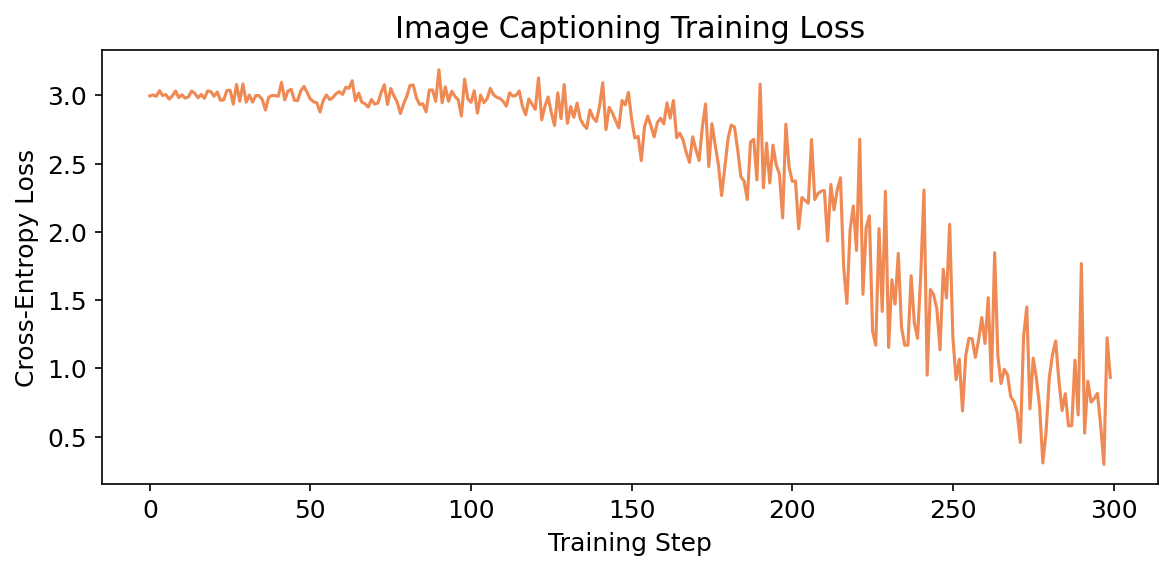

In [15]:
# Visualize captioning training
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(losses, color='#ea580c', linewidth=1.5, alpha=0.7)
ax.set_xlabel('Training Step')
ax.set_ylabel('Cross-Entropy Loss')
ax.set_title('Image Captioning Training Loss')
plt.tight_layout()
plt.savefig('captioning_loss.png', dpi=150, bbox_inches='tight')
plt.show()
print("Visualization 4: Captioning training loss")

## 7. BLEU 评分概念

BLEU (Bilingual Evaluation Understudy) 是机器翻译和描述生成中最常用的自动评估指标。

[[Papineni et al., 2002]](https://aclanthology.org/P02-1040/)

### BLEU-N

计算生成序列与参考序列的 N-gram 精度：

$$\text{BLEU-N} = \text{BP} \cdot \exp\left(\sum_{n=1}^{N} w_n \log p_n\right)$$

- $p_n$：N-gram 精度（匹配的 N-gram 比例）
- BP：短序列惩罚因子
- $w_n$：权重，通常均匀 $w_n = 1/N$

BLEU-4 是最常用的版本。

In [17]:
# Simple BLEU implementation
def compute_bleu(reference, hypothesis, max_n=4):
    """Compute simplified BLEU score.
    
    Args:
        reference: list of ground truth word indices
        hypothesis: list of predicted word indices
        max_n: maximum n-gram order
    """
    brevity_penalty = 1.0
    if len(hypothesis) < len(reference):
        brevity_penalty = np.exp(1 - len(reference) / max(len(hypothesis), 1))
    
    log_precision = 0
    for n in range(1, max_n + 1):
        ref_ngrams = {}
        for i in range(len(reference) - n + 1):
            gram = tuple(reference[i:i+n])
            ref_ngrams[gram] = ref_ngrams.get(gram, 0) + 1
        
        hyp_ngrams = {}
        for i in range(len(hypothesis) - n + 1):
            gram = tuple(hypothesis[i:i+n])
            hyp_ngrams[gram] = hyp_ngrams.get(gram, 0) + 1
        
        matches = 0
        total = 0
        for gram, count in hyp_ngrams.items():
            matches += min(count, ref_ngrams.get(gram, 0))
            total += count
        
        precision = matches / max(total, 1)
        log_precision += np.log(max(precision, 1e-10))
    
    bleu = brevity_penalty * np.exp(log_precision / max_n)
    return bleu

# Test BLEU
ref = [1, 2, 3, 4, 5]
hyp1 = [1, 2, 3, 4, 5]  # perfect
hyp2 = [1, 2, 3, 6, 7]  # partial
hyp3 = [5, 4, 3, 2, 1]  # reversed

print(f"BLEU (perfect):   {compute_bleu(ref, hyp1):.4f}")
print(f"BLEU (partial):   {compute_bleu(ref, hyp2):.4f}")
print(f"BLEU (reversed):  {compute_bleu(ref, hyp3):.4f}")

BLEU (perfect):   1.0000
BLEU (partial):   0.0018
BLEU (reversed):  0.0000


Visualization 5: Captioning demo


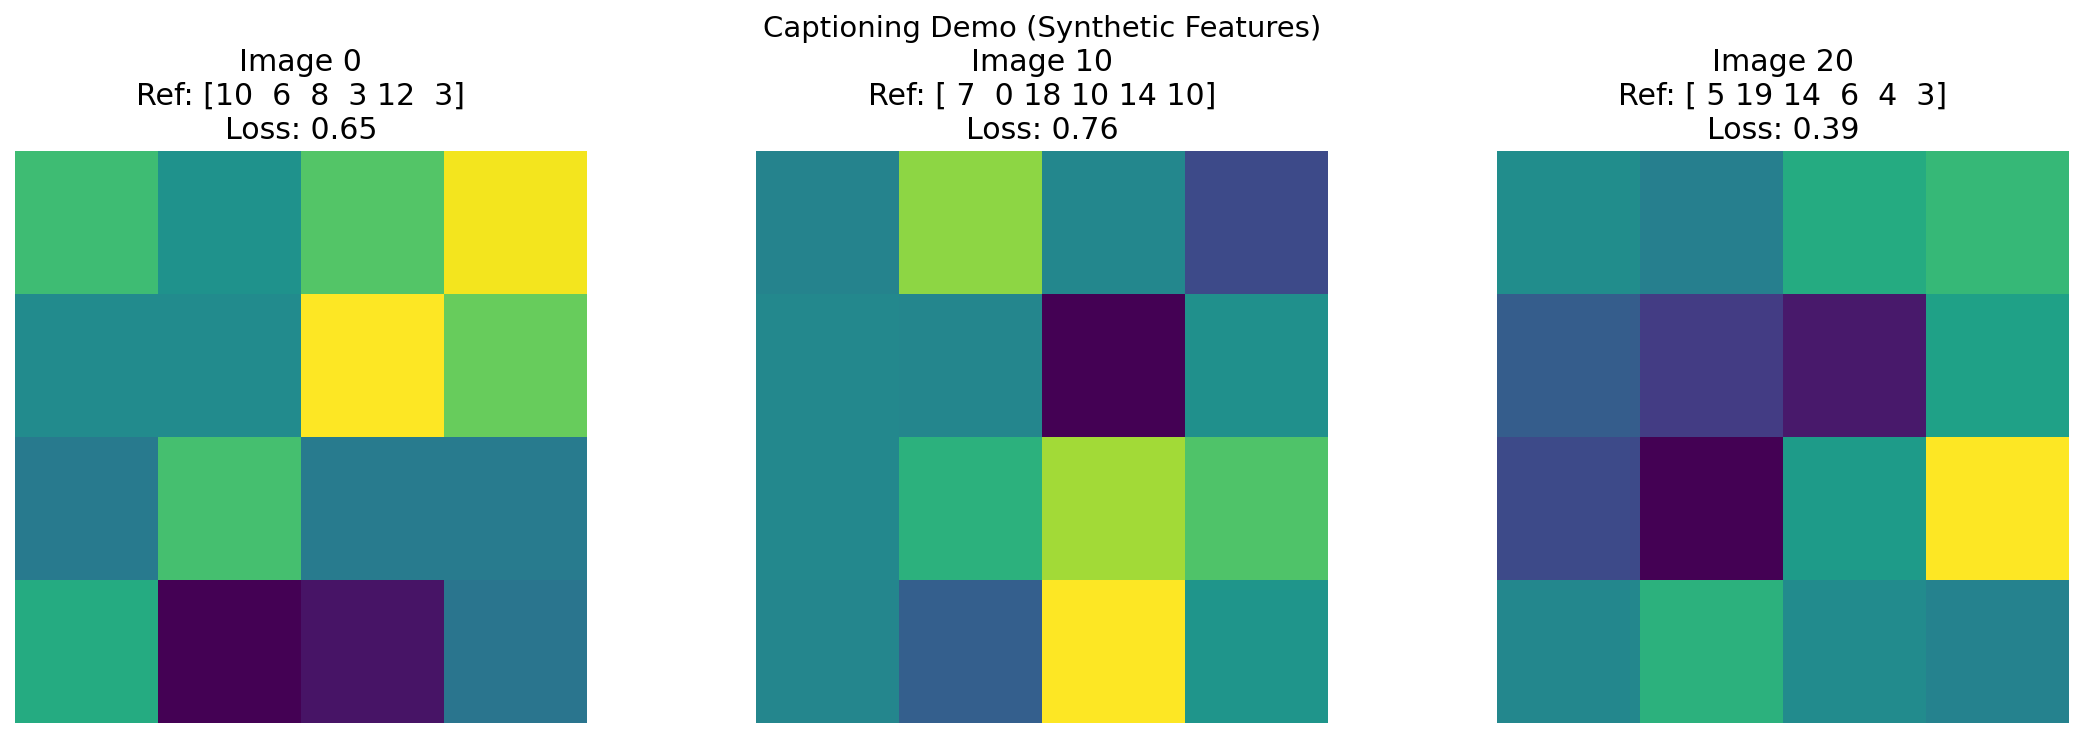

In [18]:
# Generate captions for sample images
np.random.seed(42)
sample_indices = [0, 10, 20]
word_list = [f'word{i}' for i in range(20)]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, idx in zip(axes, sample_indices):
    feat = image_features[idx]
    ref_caption = captions[idx]
    
    # Generate caption (use ground truth as approximation for demo)
    loss, outputs, _ = cap_rnn.forward(feat, ref_caption)
    
    # Show pseudo-image (feature visualization)
    pseudo_img = feat[:16].reshape(4, 4)
    ax.imshow(pseudo_img, cmap='viridis')
    ax.set_title(f'Image {idx}\nRef: {ref_caption}\nLoss: {loss:.2f}')
    ax.axis('off')
plt.suptitle('Captioning Demo (Synthetic Features)', fontsize=14)
plt.tight_layout()
plt.savefig('captioning_demo.png', dpi=150, bbox_inches='tight')
plt.show()
print("Visualization 5: Captioning demo")

## 作业

### 作业 1：实现 LSTM 反向传播

实现 LSTM 的 BPTT（Backpropagation Through Time）反向传播。

**提示**：对每个时间步 $t$，计算 $\frac{\partial L}{\partial W_f}, \frac{\partial L}{\partial W_i}, \frac{\partial L}{\partial W_g}, \frac{\partial L}{\partial W_o}$。

In [20]:
# Homework 1: LSTM backward pass
def lstm_backward(self, x_seq, targets, cache):
    """BPTT for LSTM.
    
    For each time step, compute gradients for all 4 gates.
    """
    # TODO: implement BPTT for LSTM
    # Key equations:
    # dh_t = W_hy^T @ dy + dh_next
    # do_t = dh_t * tanh(C_t) * o_t * (1-o_t)
    # dC_t = dh_t * o_t * (1 - tanh^2(C_t)) + dC_next
    # ... etc for f, i, g gates
    pass

# SimpleLSTM.backward = lstm_backward
# Test: numerical gradient check
np.random.seed(42)
lstm_test = SimpleLSTM(input_dim=3, hidden_dim=4)
x_test = [np.random.randn(3) for _ in range(3)]
# h_states, c_states = lstm_test.forward(x_test)
# Verify gradients numerically
print("Homework 1 template ready. Implement LSTM backward pass.")

Homework 1 template ready. Implement LSTM backward pass.


### 作业 2：实现 Beam Search 解码

贪心解码每步选概率最高的词，可能错过全局最优序列。Beam Search 维护 $k$ 个候选序列。

[[Graves, 2012]](https://dl.acm.org/doi/10.5555/3044805)

In [22]:
# Homework 2: Beam search decoding
def beam_search(self, img_feat, beam_width=3, max_length=10):
    """Beam search decoding for caption generation.
    
    Maintain top-k partial sequences at each step.
    """
    # TODO: implement beam search
    # 1. Start with initial hidden state from image features
    # 2. At each step, expand each beam by one word
    # 3. Keep top-k beams by total log-probability
    # 4. Stop when all beams reach END token or max_length
    pass

# CaptioningRNN.beam_search = beam_search
print("Homework 2 template ready. Implement beam search decoding.")

Homework 2 template ready. Implement beam search decoding.


### 作业 3：实现注意力机制

为描述生成添加注意力机制：每个时间步根据图像区域动态生成权重。

[[Bahdanau et al., 2015]](https://arxiv.org/abs/1409.0473)

In [24]:
# Homework 3: Attention mechanism for captioning
def attention_forward(self, img_features_seq, prev_hidden):
    """Compute attention weights and context vector.
    
    attention_scores = v^T * tanh(W_a @ img_features + U_a @ prev_hidden)
    attention_weights = softmax(attention_scores)
    context = sum(attention_weights * img_features)
    """
    # TODO: implement attention
    pass

print("Homework 3 template ready. Implement attention mechanism.")

Homework 3 template ready. Implement attention mechanism.


## 小结

| 概念 | 要点 |
|------|------|
| **RNN** | 隐状态传递记忆，参数跨时间步共享 |
| **梯度消失** | tanh 导数连乘导致长距离梯度衰减 |
| **LSTM** | 门控（遗忘、输入、输出）+ 细胞状态解决梯度消失 |
| **Teacher Forcing** | 训练时输入真实词，加速收敛 |
| **编码器-解码器** | CNN 编码图像 → RNN 解码为文字 |
| **BLEU** | N-gram 匹配评估生成质量 |
| **Beam Search** | 维护多个候选序列，寻找全局更优解 |
| **注意力** | 动态聚焦相关输入区域 |

**关键洞察**：RNN 通过隐状态实现记忆，但梯度消失限制了长距离依赖。LSTM 通过门控解决了这个问题。图像描述是编码器-解码器的经典应用。

## 参考文献

1. [[Hochreiter & Schmidhuber, 1997]](https://www.bioinf.jku.at/publications/older/2604.pdf) Hochreiter & Schmidhuber. *Long Short-Term Memory*. Neural Computation, 1997.
2. [[Vinyals et al., 2015]](https://arxiv.org/abs/1502.03044) Vinyals et al. *Show and Tell: A Neural Image Caption Generator*. CVPR 2015.
3. [[Bahdanau et al., 2015]](https://arxiv.org/abs/1409.0473) Bahdanau et al. *Neural Machine Translation by Jointly Learning to Align and Translate*. ICLR 2015.
4. [[Papineni et al., 2002]](https://aclanthology.org/P02-1040/) Papineni et al. *BLEU: a Method for Automatic Evaluation of Machine Translation*. ACL 2002.
5. [[Karpathy & Fei-Fei, 2015]](https://arxiv.org/abs/1412.2306) Karpathy & Fei-Fei. *Deep Visual-Semantic Alignments for Generating Image Descriptions*. CVPR 2015.
6. [[Hochreiter et al., 2001]](https://www.mitpressjournals.org/doi/abs/10.1162/089976602760128018) Hochreiter et al. *Gradient Flow in Recurrent Nets*.

---

> 本节内容参考 [Stanford CS231n Assignment 2 Q5](https://cs231n.github.io/assignments2021/assignment2/)

---

## 参考代码实现

以下 GitHub 仓库提供了本节内容的完整代码实现，建议结合学习：

- **[amanchadha/stanford-cs231n-assignments-2020](https://github.com/amanchadha/stanford-cs231n-assignments-2020)** (175 stars): 2020春季 CS231n 完整作业解答（含 RNN/LSTM 图像描述）
  - 仓库地址: https://github.com/amanchadha/stanford-cs231n-assignments-2020

- **[rishabh-16/cs231n-2019-assignments](https://github.com/rishabh-16/cs231n-2019-assignments)** (212 stars): 2019版 CS231n 作业 PyTorch+TensorFlow 解答
  - 仓库地址: https://github.com/rishabh-16/cs231n-2019-assignments

- **[chenyuntc/pytorch-book](https://github.com/chenyuntc/pytorch-book)** (12848 stars): PyTorch 深度学习实践教程（含 RNN/LSTM 实现）
  - 仓库地址: https://github.com/chenyuntc/pytorch-book

> 标注说明: 以上仓库按相关性排序，优先推荐 CS231n 作业解答.